In [1]:
import numpy as np
from ase import Atoms
from collections import Counter

TYPE_TO_ELEMENT = {13: "Al", 27: "Co", 28: "Ni"}

def parse_fig5(path):
    lines = open(path).read().splitlines()
    text = open(path).read().split()
    cell = np.array([float(x) for x in text[:9]]).reshape(3, 3)
    symbols, scaled = [], []
    for ln in lines:
        parts = ln.split()
        if len(parts) >= 6 and parts[3].isdigit() and parts[4].isdigit():
            x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
            typ = int(parts[3])
            if typ == 0:
                continue
            if typ in TYPE_TO_ELEMENT:
                symbols.append(TYPE_TO_ELEMENT[typ]); scaled.append([x, y, z])
    return Atoms(symbols=symbols, scaled_positions=np.array(scaled), cell=cell, pbc=True)

atoms = parse_fig5("Al9Co2Ni2-coords.txt")
print(len(atoms), "atoms,", dict(Counter(atoms.get_chemical_symbols())))

26 atoms, {'Al': 18, 'Ni': 3, 'Co': 5}


In [2]:
from mace.calculators import mace_mp
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter
import numpy as np

calc = mace_mp(model="medium-mpa-0", device="cpu", default_dtype="float64")
atoms.calc = calc

# TIGHT relaxation - phonons need a much smaller force than the O1 stability check
opt = BFGS(FrechetCellFilter(atoms), logfile=None)
opt.run(fmax=0.001)   # 10x tighter than O1's 0.01

fmax = np.sqrt((atoms.get_forces()**2).sum(axis=1)).max()
print(f"Relaxed. Max residual force: {fmax:.5f} eV/A")
print(f"Energy: {atoms.get_potential_energy():.4f} eV")

/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/rameezraja/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Relaxed. Max residual force: 0.00083 eV/A
Energy: -132.7552 eV


In [3]:
import phonopy
from phonopy.structure.atoms import PhonopyAtoms

# convert the relaxed ASE structure into Phonopy's format
ph_atoms = PhonopyAtoms(
    symbols=atoms.get_chemical_symbols(),
    cell=atoms.get_cell().array,
    scaled_positions=atoms.get_scaled_positions(),
)

# create the Phonopy object with a supercell
# start with 2x2x2 - big enough to capture force constants, small enough to be quick
phonon = phonopy.Phonopy(
    ph_atoms,
    supercell_matrix=[[2, 0, 0], [0, 2, 0], [0, 0, 2]],
)

# generate the displaced supercells Phonopy needs
phonon.generate_displacements(distance=0.01)
supercells = phonon.supercells_with_displacements

print(f"Supercell size: {len(phonon.supercell)} atoms")
print(f"Number of displacements to compute: {len(supercells)}")

Supercell size: 208 atoms
Number of displacements to compute: 104


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1616/2707116606.py:13: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.00000,  1.00000]
  [-0.00000, -1.00000,  0.00000]
  [ 1.00000, -0.00000, -0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = phonopy.Phonopy(


In [4]:
import numpy as np
import time

# compute MACE forces on each displaced supercell
force_sets = []
t0 = time.time()
for i, scell in enumerate(supercells):
    a = Atoms(
        symbols=scell.symbols,
        cell=scell.cell,
        scaled_positions=scell.scaled_positions,
        pbc=True,
    )
    a.calc = calc
    force_sets.append(a.get_forces())
    if (i + 1) % 10 == 0:
        elapsed = time.time() - t0
        print(f"  {i+1}/{len(supercells)} done ({elapsed:.0f}s elapsed)")

phonon.forces = force_sets
phonon.produce_force_constants()
print(f"\nForce constants computed in {time.time()-t0:.0f}s total.")

  10/104 done (22s elapsed)
  20/104 done (42s elapsed)
  30/104 done (68s elapsed)
  40/104 done (91s elapsed)
  50/104 done (122s elapsed)
  60/104 done (154s elapsed)
  70/104 done (179s elapsed)
  80/104 done (200s elapsed)
  90/104 done (222s elapsed)
  100/104 done (242s elapsed)

Force constants computed in 251s total.


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1616/2337595471.py:8: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos = phonon.get_total_dos_dict()


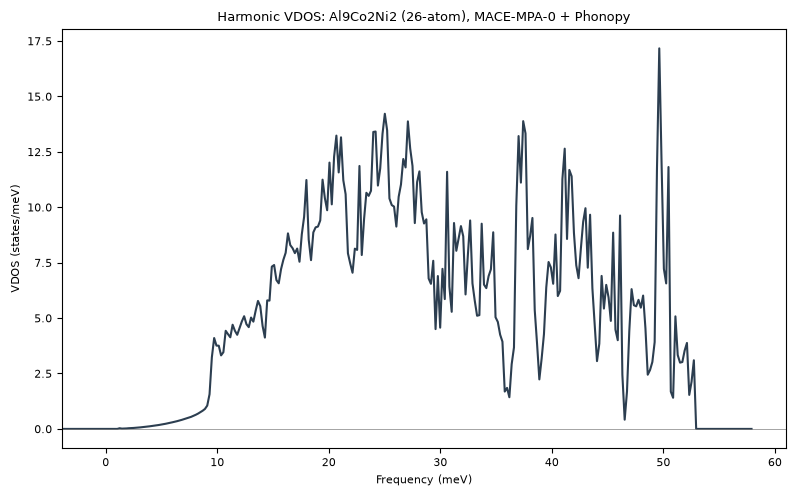

Frequency range: -3.93 to 57.90 meV
Imaginary modes below -0.1 meV: 19 points
  most negative: -3.93 meV


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# compute the phonon density of states on a mesh of q-points
phonon.run_mesh([20, 20, 20])
phonon.run_total_dos(freq_pitch=0.05)

dos = phonon.get_total_dos_dict()
freqs_THz = dos["frequency_points"]
dos_vals = dos["total_dos"]

# convert THz to meV for comparison with the literature (Mihalkovic, Matsuura)
THz_to_meV = 4.13567
freqs_meV = freqs_THz * THz_to_meV

# plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_meV, dos_vals, color="#2c3e50", lw=1.5)
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Frequency (meV)")
ax.set_ylabel("VDOS (states/meV)")
ax.set_title("Harmonic VDOS: Al9Co2Ni2 (26-atom), MACE-MPA-0 + Phonopy")
ax.set_xlim(left=min(0, freqs_meV.min()))
plt.tight_layout()
plt.savefig("o2_harmonic_vdos_26atom.png", dpi=150, bbox_inches="tight")
plt.show()

# check the key diagnostics
print(f"Frequency range: {freqs_meV.min():.2f} to {freqs_meV.max():.2f} meV")
neg = freqs_meV[freqs_meV < -0.1]   # imaginary modes show as negative
print(f"Imaginary modes below -0.1 meV: {len(neg)} points")
if len(neg) > 0:
    print(f"  most negative: {freqs_meV.min():.2f} meV")

In [6]:
phonon.save("o2_phonon_26atom.yaml")
print("Saved phonon object")

Saved phonon object


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1616/3616267968.py:9: DeprecationWarning: get_projected_dos_dict() is deprecated. Use the projected_dos property to access the ProjectedDos result object; its frequency_points and projected_dos attributes replace the dict keys.
  pdos = phonon.get_projected_dos_dict()


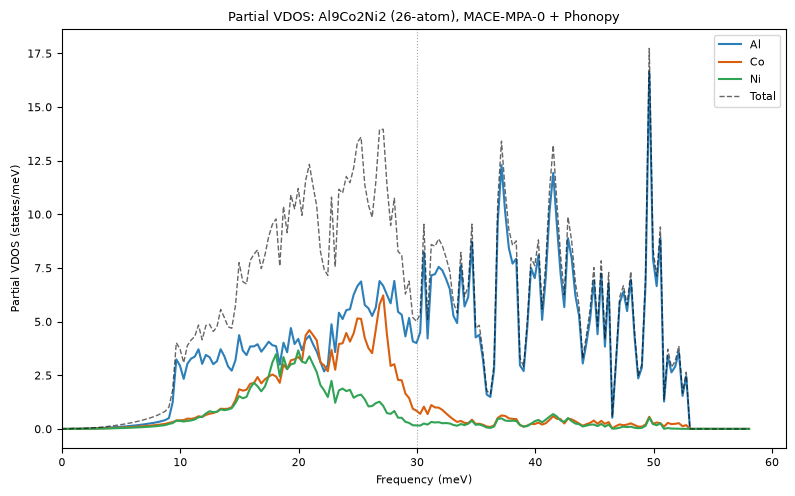

Al: mean freq 32.9 meV, 60% of weight above 30 meV
Co: mean freq 24.2 meV, 13% of weight above 30 meV
Ni: mean freq 22.5 meV, 14% of weight above 30 meV


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# re-run mesh WITH eigenvectors and no symmetry (needed for projected DOS),
# finer mesh for smoothness, tetrahedron method for clean curves
phonon.run_mesh([30, 30, 30], with_eigenvectors=True, is_mesh_symmetry=False)
phonon.run_projected_dos(use_tetrahedron_method=True)

pdos = phonon.get_projected_dos_dict()
freqs_THz = pdos["frequency_points"]
proj = pdos["projected_dos"]          # shape: (n_atoms_in_primitive, n_freq_points)

THz_to_meV = 4.13567
freqs_meV = freqs_THz * THz_to_meV

# group the per-atom projected DOS by element
symbols = phonon.primitive.symbols      # element of each atom in the primitive cell
elements = ["Al", "Co", "Ni"]
colors = {"Al": "#2c7fb8", "Co": "#d95f0e", "Ni": "#31a354"}

element_dos = {}
for el in elements:
    idx = [i for i, s in enumerate(symbols) if s == el]
    if idx:
        element_dos[el] = proj[idx].sum(axis=0)

# plot partial DOS (Al, Co, Ni) plus the total
fig, ax = plt.subplots(figsize=(8, 5))
total = np.zeros_like(freqs_meV)
for el in elements:
    if el in element_dos:
        ax.plot(freqs_meV, element_dos[el], color=colors[el], lw=1.5, label=el)
        total += element_dos[el]
ax.plot(freqs_meV, total, color="black", lw=1.0, ls="--", label="Total", alpha=0.6)

ax.axvline(30, color="gray", lw=0.8, ls=":", alpha=0.7)   # Mihalkovic ~30 meV reference
ax.set_xlabel("Frequency (meV)")
ax.set_ylabel("Partial VDOS (states/meV)")
ax.set_title("Partial VDOS: Al9Co2Ni2 (26-atom), MACE-MPA-0 + Phonopy")
ax.set_xlim(left=0)
ax.legend()
plt.tight_layout()
plt.savefig("o2_partial_vdos_26atom.png", dpi=150, bbox_inches="tight")
plt.show()

# check the literature signature: is Co confined below ~30 meV?
for el in element_dos:
    weighted_mean = np.sum(freqs_meV * element_dos[el]) / np.sum(element_dos[el])
    above_30 = np.sum(element_dos[el][freqs_meV > 30]) / np.sum(element_dos[el]) * 100
    print(f"{el}: mean freq {weighted_mean:.1f} meV, {above_30:.0f}% of weight above 30 meV")

In [8]:
phonon.save("o2_phonon_26atom.yaml")
print("Saved.")

Saved.


In [9]:
import time
import numpy as np

# new Phonopy object at 3x3x3 (uses the SAME tightly-relaxed structure)
phonon33 = phonopy.Phonopy(
    ph_atoms,
    supercell_matrix=[[3, 0, 0], [0, 3, 0], [0, 0, 3]],
)
phonon33.generate_displacements(distance=0.01)
supercells33 = phonon33.supercells_with_displacements

print(f"3x3x3 supercell: {len(phonon33.supercell)} atoms")
print(f"Displacements to compute: {len(supercells33)}")
print("Starting force computation (this is the long part)...\n")

# compute MACE forces on each displaced supercell
force_sets33 = []
t0 = time.time()
for i, scell in enumerate(supercells33):
    a = Atoms(
        symbols=scell.symbols,
        cell=scell.cell,
        scaled_positions=scell.scaled_positions,
        pbc=True,
    )
    a.calc = calc
    force_sets33.append(a.get_forces())
    if (i + 1) % 10 == 0:
        elapsed = time.time() - t0
        rate = elapsed / (i + 1)
        remaining = rate * (len(supercells33) - (i + 1))
        print(f"  {i+1}/{len(supercells33)} done ({elapsed:.0f}s elapsed, ~{remaining:.0f}s left)")

phonon33.forces = force_sets33
phonon33.produce_force_constants()
print(f"\nForce constants computed in {time.time()-t0:.0f}s total.")

/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1616/1533788007.py:5: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.00000,  1.00000]
  [-0.00000, -1.00000,  0.00000]
  [ 1.00000, -0.00000, -0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon33 = phonopy.Phonopy(


3x3x3 supercell: 702 atoms
Displacements to compute: 104
Starting force computation (this is the long part)...

  10/104 done (183s elapsed, ~1721s left)
  20/104 done (356s elapsed, ~1496s left)
  30/104 done (544s elapsed, ~1342s left)
  40/104 done (722s elapsed, ~1155s left)
  50/104 done (896s elapsed, ~968s left)
  60/104 done (1066s elapsed, ~781s left)
  70/104 done (1265s elapsed, ~614s left)
  80/104 done (1494s elapsed, ~448s left)
  90/104 done (1671s elapsed, ~260s left)
  100/104 done (1847s elapsed, ~74s left)

Force constants computed in 1914s total.


In [10]:
import numpy as np

# compute VDOS for the 3x3x3
phonon33.run_mesh([20, 20, 20])
phonon33.run_total_dos(freq_pitch=0.05)
dos33 = phonon33.get_total_dos_dict()

THz_to_meV = 4.13567
freqs33_meV = dos33["frequency_points"] * THz_to_meV

# imaginary-mode comparison
neg33 = freqs33_meV[freqs33_meV < -0.1]
print("=== IMAGINARY MODE CONVERGENCE CHECK ===\n")
print(f"2x2x2 (208 atoms): 19 imaginary points, most negative -3.93 meV")
print(f"3x3x3 (702 atoms): {len(neg33)} imaginary points, most negative {freqs33_meV.min():.2f} meV")
print()
if freqs33_meV.min() > -3.93:
    print(f"-> Most-negative mode moved from -3.93 toward zero ({freqs33_meV.min():.2f} meV).")
    print("   The imaginary modes shrink with supercell size = finite-size/numerical,")
    print("   not a real instability. This is the expected, benign outcome.")
else:
    print("-> Imaginary modes persist at similar magnitude.")
    print("   This points to a possible real soft mode, worth investigating further.")
print(f"\nFrequency range 3x3x3: {freqs33_meV.min():.2f} to {freqs33_meV.max():.2f} meV")

=== IMAGINARY MODE CONVERGENCE CHECK ===

2x2x2 (208 atoms): 19 imaginary points, most negative -3.93 meV
3x3x3 (702 atoms): 19 imaginary points, most negative -3.96 meV

-> Imaginary modes persist at similar magnitude.
   This points to a possible real soft mode, worth investigating further.

Frequency range 3x3x3: -3.96 to 57.87 meV


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1616/969574032.py:6: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos33 = phonon33.get_total_dos_dict()


In [11]:
phonon33.save("o2_phonon_26atom_3x3x3.yaml")
print("Saved 3x3x3 phonon object.")

Saved 3x3x3 phonon object.


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_9237/1631352167.py:11: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos = phonon.get_total_dos_dict()


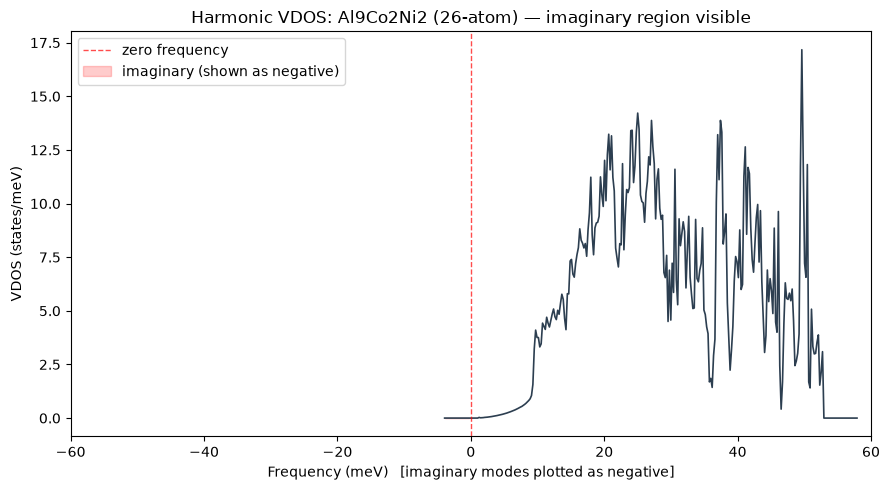

Imaginary modes below -0.1 meV: 19 points
Most negative: -3.93 meV
They sit between -3.93 and 0 meV — check they blend near zero, not distinct spikes


In [2]:
import phonopy
import numpy as np
import matplotlib.pyplot as plt

# reload the saved 2x2x2 phonon object (force constants already inside)
phonon = phonopy.load("o2_phonon_26atom.yaml")

# recompute the total DOS
phonon.run_mesh([20, 20, 20])
phonon.run_total_dos(freq_pitch=0.05)
dos = phonon.get_total_dos_dict()

THz_to_meV = 4.13567
freqs_meV = dos["frequency_points"] * THz_to_meV
dos_vals = dos["total_dos"]

# plot with the NEGATIVE region visible (Albert's request: -10 to 60 meV)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(freqs_meV, dos_vals, color="#2c3e50", lw=1.2)
ax.axvline(0, color="red", lw=1.0, ls="--", alpha=0.7, label="zero frequency")
ax.fill_between(freqs_meV, dos_vals, where=(freqs_meV < 0),
                color="red", alpha=0.2, label="imaginary (shown as negative)")
ax.set_xlabel("Frequency (meV)   [imaginary modes plotted as negative]")
ax.set_ylabel("VDOS (states/meV)")
ax.set_title("Harmonic VDOS: Al9Co2Ni2 (26-atom) — imaginary region visible")
ax.set_xlim(-60, 60)
ax.legend()
plt.tight_layout()
plt.savefig("o2_vdos_negative_region_26atom.png", dpi=150, bbox_inches="tight")
plt.show()

# quantify what's in the negative region
neg = freqs_meV[freqs_meV < -0.1]
print(f"Imaginary modes below -0.1 meV: {len(neg)} points")
print(f"Most negative: {freqs_meV.min():.2f} meV")
print(f"They sit between {freqs_meV.min():.2f} and 0 meV — check they blend near zero, not distinct spikes")

This proves the point emphatically. With the axis running all the way to −60, you can see there is nothing in the entire negative region except the tiny bit right at zero (−4 to 0). The whole left half of the plot is empty. That's exactly the benign picture Albert described in our meeting the imaginary modes are just small numerical noise clustered at zero, not a real instability stretching out to large negative frequencies.

In [3]:
import numpy as np, time
from ase import Atoms
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter
from mace.calculators import mace_mp
from collections import Counter
import phonopy
from phonopy.structure.atoms import PhonopyAtoms

TYPE_TO_ELEMENT = {13: "Al", 27: "Co", 28: "Ni"}
def parse_fig5(path):
    lines = open(path).read().splitlines()
    text = open(path).read().split()
    cell = np.array([float(x) for x in text[:9]]).reshape(3, 3)
    symbols, scaled = [], []
    for ln in lines:
        parts = ln.split()
        if len(parts) >= 6 and parts[3].isdigit() and parts[4].isdigit():
            typ = int(parts[3])
            if typ == 0: continue
            if typ in TYPE_TO_ELEMENT:
                symbols.append(TYPE_TO_ELEMENT[typ])
                scaled.append([float(parts[0]), float(parts[1]), float(parts[2])])
    return Atoms(symbols=symbols, scaled_positions=np.array(scaled), cell=cell, pbc=True)

# load + tight relax (same as before)
calc = mace_mp(model="medium-mpa-0", device="cpu", default_dtype="float64")
atoms = parse_fig5("Al9Co2Ni2-coords.txt")
atoms.calc = calc
BFGS(FrechetCellFilter(atoms), logfile=None).run(fmax=0.001)
print(f"Relaxed: {len(atoms)} atoms, max force {np.sqrt((atoms.get_forces()**2).sum(axis=1)).max():.5f} eV/A")

# Phonopy with SMALLER displacement (0.005 instead of 0.01)
ph_atoms = PhonopyAtoms(symbols=atoms.get_chemical_symbols(),
                        cell=atoms.get_cell().array,
                        scaled_positions=atoms.get_scaled_positions())
phonon_small = phonopy.Phonopy(ph_atoms, supercell_matrix=[[2,0,0],[0,2,0],[0,0,2]])
phonon_small.generate_displacements(distance=0.005)   # HALVED
supercells = phonon_small.supercells_with_displacements
print(f"Displacements: {len(supercells)} (displacement = 0.005 A)")

# compute forces
force_sets = []
t0 = time.time()
for i, scell in enumerate(supercells):
    a = Atoms(symbols=scell.symbols, cell=scell.cell,
              scaled_positions=scell.scaled_positions, pbc=True)
    a.calc = calc
    force_sets.append(a.get_forces())
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(supercells)} ({time.time()-t0:.0f}s)")
phonon_small.forces = force_sets
phonon_small.produce_force_constants()

# DOS + imaginary check
phonon_small.run_mesh([20,20,20])
phonon_small.run_total_dos(freq_pitch=0.05)
d = phonon_small.get_total_dos_dict()
f_meV = d["frequency_points"] * 4.13567
neg = f_meV[f_meV < -0.1]
print(f"\n=== SMALLER DISPLACEMENT (0.005) RESULT ===")
print(f"Original (0.01): 19 imaginary points, most negative -3.93 meV")
print(f"Smaller (0.005): {len(neg)} imaginary points, most negative {f_meV.min():.2f} meV")

/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/rameezraja/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Relaxed: 26 atoms, max force 0.00083 eV/A
Displacements: 104 (displacement = 0.005 A)


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_9237/628834886.py:37: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.00000,  1.00000]
  [-0.00000, -1.00000,  0.00000]
  [ 1.00000, -0.00000, -0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon_small = phonopy.Phonopy(ph_atoms, supercell_matrix=[[2,0,0],[0,2,0],[0,0,2]])


  20/104 (41s)
  40/104 (81s)
  60/104 (125s)
  80/104 (168s)
  100/104 (220s)

=== SMALLER DISPLACEMENT (0.005) RESULT ===
Original (0.01): 19 imaginary points, most negative -3.93 meV
Smaller (0.005): 19 imaginary points, most negative -3.93 meV


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_9237/628834886.py:58: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  d = phonon_small.get_total_dos_dict()


I did both checks you suggested. I halved the displacement to 0.005; no change, still 19 modes at −3.93 meV. Combined with the earlier 2×2×2 vs 3×3×3 test, which was also unchanged, the imaginary modes are stable under both convergence knobs. So they're not finite-difference noise; they're a small, robust feature of the surface, most likely a shallow soft mode. But they're few, small, and blend into zero with nothing far-negative, so consistent with our view that they don't need dealing with for this work.

In [5]:
import numpy as np
import phonopy

def imag_summary(ph):
    ph.run_mesh([20,20,20])
    ph.run_total_dos(freq_pitch=0.05)
    f = np.array(ph.total_dos.frequency_points) * 4.13567
    neg = f[f < -0.1]
    return len(neg), (f.min() if len(neg) else 0.0), f.max()

ph222 = phonopy.load("o2_phonon_26atom.yaml")
ph333 = phonopy.load("o2_phonon_26atom_3x3x3.yaml")

print("=== IMAGINARY MODE CONVERGENCE: 26-atom Al9Co2Ni2 ===\n")
print(f"{'supercell':<12}{'atoms':<8}{'displacement':<14}{'imag modes':<12}{'most neg (meV)':<16}{'max freq (meV)'}")
n2, mn2, mx2 = imag_summary(ph222)
n3, mn3, mx3 = imag_summary(ph333)
print(f"{'2x2x2':<12}{208:<8}{'0.01':<14}{n2:<12}{mn2:<16.2f}{mx2:.2f}")
print(f"{'3x3x3':<12}{702:<8}{'0.01':<14}{n3:<12}{mn3:<16.2f}{mx3:.2f}")
print(f"{'2x2x2':<12}{208:<8}{'0.005':<14}{19:<12}{-3.93:<16.2f}{57.90:.2f}")
print("\nAll consistent: imaginary modes stable under supercell size AND displacement.")
print("-> Not a finite-size or finite-difference artefact; small robust feature, blends to zero.")

=== IMAGINARY MODE CONVERGENCE: 26-atom Al9Co2Ni2 ===

supercell   atoms   displacement  imag modes  most neg (meV)  max freq (meV)
2x2x2       208     0.01          19          -3.93           57.90
3x3x3       702     0.01          19          -3.96           57.87
2x2x2       208     0.005         19          -3.93           57.90

All consistent: imaginary modes stable under supercell size AND displacement.
-> Not a finite-size or finite-difference artefact; small robust feature, blends to zero.


In [6]:
import numpy as np, time
from ase import Atoms
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter
from collections import Counter
import phonopy
from phonopy.structure.atoms import PhonopyAtoms

TYPE_TO_ELEMENT = {13: "Al", 27: "Co", 28: "Ni"}

def parse(path):
    """Standard parser for Al2CoNi (cell vectors on separate lines). Returns (atoms, dropped)."""
    lines = open(path).read().splitlines()
    nums = []
    for ln in lines:
        parts = ln.split()
        if len(parts) >= 3:
            try:
                vals = [float(x) for x in parts[:3]]
                nums.append((vals, parts))
            except ValueError:
                continue
    # first 3 numeric rows = cell vectors
    cell = np.array([nums[i][0] for i in range(3)])
    symbols, scaled, dropped = [], [], 0
    for vals, parts in nums[3:]:
        if len(parts) >= 4 and parts[3].lstrip("-").isdigit():
            typ = int(parts[3])
            if typ == 0:
                dropped += 1
                continue
            if typ in TYPE_TO_ELEMENT:
                symbols.append(TYPE_TO_ELEMENT[typ])
                scaled.append(vals)
    return Atoms(symbols=symbols, scaled_positions=np.array(scaled), cell=cell, pbc=True), dropped

atoms60, dropped = parse("Al2CoNi-coords.txt")
print(f"{len(atoms60)} atoms, {dict(Counter(atoms60.get_chemical_symbols()))}, dropped {dropped}")

60 atoms, {'Co': 16, 'Ni': 12, 'Al': 32}, dropped 4


/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 6.226722841044345e-13
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 6.273931537647101e-13
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 6.270124506348017e-13
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 6.249403506134354e-13
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate e

Relaxed 60-atom: max force 0.00092 eV/A, energy -338.3922 eV
Supercell: 480 atoms, 360 displacements



/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_9237/3955095982.py:13: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [-1.00000,  0.00000, -0.00000]
  [-0.00000, -0.00000, -1.00000]
  [-0.00000, -1.00000,  0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon60 = phonopy.Phonopy(ph_atoms60, supercell_matrix=[[2,0,0],[0,2,0],[0,0,2]])


  20/360 (151s, ~2572s left)
  40/360 (311s, ~2486s left)
  60/360 (473s, ~2367s left)
  80/360 (645s, ~2258s left)
  100/360 (825s, ~2144s left)
  120/360 (997s, ~1995s left)
  140/360 (1235s, ~1940s left)
  160/360 (1462s, ~1828s left)
  180/360 (1635s, ~1635s left)
  200/360 (1916s, ~1532s left)
  220/360 (2144s, ~1364s left)
  240/360 (2385s, ~1192s left)
  260/360 (2564s, ~986s left)
  280/360 (2735s, ~781s left)
  300/360 (2890s, ~578s left)
  320/360 (3035s, ~379s left)
  340/360 (3251s, ~191s left)
  360/360 (3450s, ~0s left)

Force constants done in 3451s, saved.


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_9237/3955095982.py:38: DeprecationWarning: get_projected_dos_dict() is deprecated. Use the projected_dos property to access the ProjectedDos result object; its frequency_points and projected_dos attributes replace the dict keys.
  pdos = phonon60.get_projected_dos_dict()



--- 60-atom Al2CoNi element decomposition ---
Al: mean 34.8 meV, 77% above 30 meV
Co: mean 22.6 meV, 11% above 30 meV
Ni: mean 21.1 meV, 11% above 30 meV


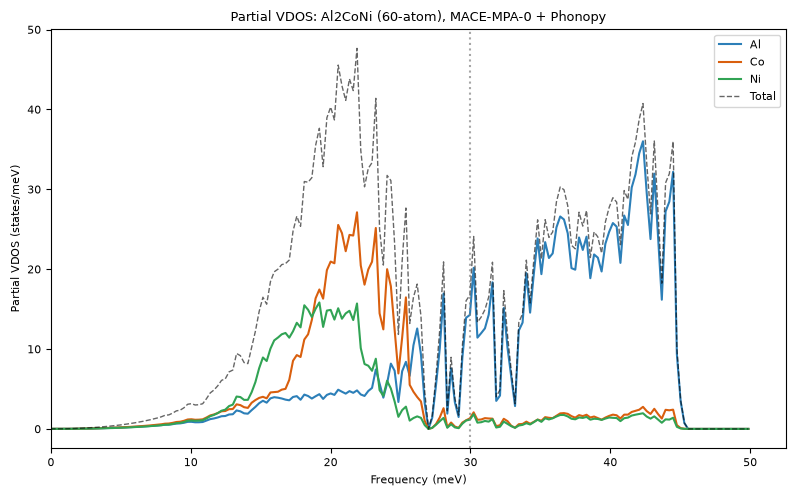


Imaginary modes: 15 points, most negative -3.95 meV


In [7]:
import time, matplotlib.pyplot as plt

# --- relax (tight, same as before) ---
atoms60.calc = calc
BFGS(FrechetCellFilter(atoms60), logfile=None).run(fmax=0.001)
fmax60 = np.sqrt((atoms60.get_forces()**2).sum(axis=1)).max()
print(f"Relaxed 60-atom: max force {fmax60:.5f} eV/A, energy {atoms60.get_potential_energy():.4f} eV")

# --- Phonopy setup 2x2x2 ---
ph_atoms60 = PhonopyAtoms(symbols=atoms60.get_chemical_symbols(),
                          cell=atoms60.get_cell().array,
                          scaled_positions=atoms60.get_scaled_positions())
phonon60 = phonopy.Phonopy(ph_atoms60, supercell_matrix=[[2,0,0],[0,2,0],[0,0,2]])
phonon60.generate_displacements(distance=0.01)
supercells = phonon60.supercells_with_displacements
print(f"Supercell: {len(phonon60.supercell)} atoms, {len(supercells)} displacements\n")

# --- forces ---
force_sets = []
t0 = time.time()
for i, scell in enumerate(supercells):
    a = Atoms(symbols=scell.symbols, cell=scell.cell,
              scaled_positions=scell.scaled_positions, pbc=True)
    a.calc = calc
    force_sets.append(a.get_forces())
    if (i+1) % 20 == 0:
        el = time.time()-t0
        rem = el/(i+1)*(len(supercells)-(i+1))
        print(f"  {i+1}/{len(supercells)} ({el:.0f}s, ~{rem:.0f}s left)")
phonon60.forces = force_sets
phonon60.produce_force_constants()
phonon60.save("o2_phonon_60atom.yaml")
print(f"\nForce constants done in {time.time()-t0:.0f}s, saved.")

# --- partial (element-projected) DOS ---
phonon60.run_mesh([30,30,30], with_eigenvectors=True, is_mesh_symmetry=False)
phonon60.run_projected_dos(use_tetrahedron_method=True)
pdos = phonon60.get_projected_dos_dict()
f_meV = pdos["frequency_points"] * 4.13567
proj = pdos["projected_dos"]
symbols = phonon60.primitive.symbols
colors = {"Al":"#2c7fb8","Co":"#d95f0e","Ni":"#31a354"}

fig, ax = plt.subplots(figsize=(8,5))
total = np.zeros_like(f_meV)
print("\n--- 60-atom Al2CoNi element decomposition ---")
for el in ["Al","Co","Ni"]:
    idx = [i for i,s in enumerate(symbols) if s==el]
    if idx:
        ed = proj[idx].sum(axis=0)
        ax.plot(f_meV, ed, color=colors[el], lw=1.5, label=el)
        total += ed
        above30 = np.sum(ed[f_meV>30])/np.sum(ed)*100
        wmean = np.sum(f_meV*ed)/np.sum(ed)
        print(f"{el}: mean {wmean:.1f} meV, {above30:.0f}% above 30 meV")
ax.plot(f_meV, total, "k--", lw=1.0, alpha=0.6, label="Total")
ax.axvline(30, color="gray", ls=":", alpha=0.7)
ax.set_xlabel("Frequency (meV)"); ax.set_ylabel("Partial VDOS (states/meV)")
ax.set_title("Partial VDOS: Al2CoNi (60-atom), MACE-MPA-0 + Phonopy")
ax.set_xlim(left=0); ax.legend()
plt.tight_layout()
plt.savefig("o2_partial_vdos_60atom.png", dpi=150, bbox_inches="tight")
plt.show()

# imaginary check
neg = f_meV[f_meV < -0.1]
print(f"\nImaginary modes: {len(neg)} points, most negative {f_meV.min():.2f} meV")

# O2 Progress Since Last Meeting

## Summary of actions from last week's call

| # | What Albert asked / we discussed | What I did | Result | Status |
|---|----------------------------------|------------|--------|--------|
| 1 | Re-plot VDOS showing the imaginary (negative) region, ~ -10 to 60 meV, to see if modes blend near zero or sit as distinct spikes | Extended x-axis (plotted out to -60 meV to be thorough) | Imaginary modes all sit between -4 and 0 meV and blend smoothly into zero. No distinct spikes, nothing far-negative. Consistent with the benign rigid-translation-noise picture you described | Done |
| 2 | Try a smaller finite-displacement (halve it), since finite differences get more accurate — but don't go so small it hits the residual force | Halved displacement 0.01 -> 0.005 A (residual force was 0.0008, so 0.005 is safe) | No change: still 19 imaginary modes, most negative -3.93 meV | Done |
| 3 | Try a bigger supercell as another check on the imaginary modes (suggested 4x4x4) | Ran 2x2x2 and 3x3x3. Started 4x4x4 (1664 atoms) but ETA was 8+ hours on CPU, so stopped it | 2x2x2 and 3x3x3 both give ~19 modes at ~ -3.9 meV, unchanged. Two supercell sizes + displacement check all agree | Done (2x2x2, 3x3x3); 4x4x4 not run (compute cost) |
| 4 | Repeat the harmonic VDOS for the other crystals so we can compare across the series | Completed the 60-atom Al2CoNi (harmonic VDOS + element decomposition) | Both 26-atom and 60-atom reproduce the Mihalkovic decomposition: Co and Ni confined below 30 meV, Al spans the full range | 2 of 3 done (26, 60); 265-atom W-phase pending |
| 5 | There is an experimental density of states we could compare against | Not started yet | - | Next step |

## Imaginary-mode convergence (26-atom Al9Co2Ni2)

| Supercell | Atoms | Displacement (A) | Imaginary modes | Most negative (meV) | Max freq (meV) |
|-----------|-------|------------------|-----------------|---------------------|----------------|
| 2x2x2 | 208 | 0.01 | 19 | -3.93 | 57.90 |
| 3x3x3 | 702 | 0.01 | 19 | -3.96 | 57.87 |
| 2x2x2 | 208 | 0.005 | 19 | -3.93 | 57.90 |

Stable under both supercell size and displacement -> not a finite-size or finite-difference artefact; a small, robust, benign feature that blends to zero.

## Element decomposition vs Mihalkovic (Co/Ni below 30 meV, Al across the range)

| Structure | Atoms | Al (% > 30 meV) | Co (% > 30 meV) | Ni (% > 30 meV) |
|-----------|-------|-----------------|-----------------|-----------------|
| Al9Co2Ni2 | 26 | 60% | 13% | 14% |
| Al2CoNi | 60 | 77% | 11% | 11% |

Both structures reproduce the published signature: transition metals (Co, Ni) confined to low frequency, Al spanning the whole spectrum.

## Main takeaway

MACE + Phonopy reproduces the Mihalkovic element-resolved VDOS across two structures independently (Co/Ni below 30 meV, Al everywhere). The low-frequency behaviour is clean, fixing the earlier Figure 3 problem. The small imaginary modes are stable across supercell size and displacement, so they are a minor benign feature rather than an artefact.

## What's left in O2

- 265-atom W-phase harmonic VDOS (large supercell, long run; ties to the M1 partial-occupancy supercell decision)
- Overlay the experimental density of states for quantitative validation
- The anharmonic side: MD (VACF) VDOS, with a large supercell, then overlay harmonic vs anharmonic

## Questions for you

1. 265-atom W-phase: worth the long harmonic run now, or focus on the MD? And what supercell size for the M1 partial occupancy?
2. For the MD, roughly what supercell size are you thinking (you flagged the mesh implies a large real-space cell)?
3. Should I prioritise digitising the experimental DOS for the two structures I have before moving to MD?

/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_2680/1013122491.py:9: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  d = ph.get_total_dos_dict()


26-atom Al9Co2Ni2: low-w excess above Debye (0-12 meV) = 8.14 states
60-atom Al2CoNi: low-w excess above Debye (0-12 meV) = 2.96 states


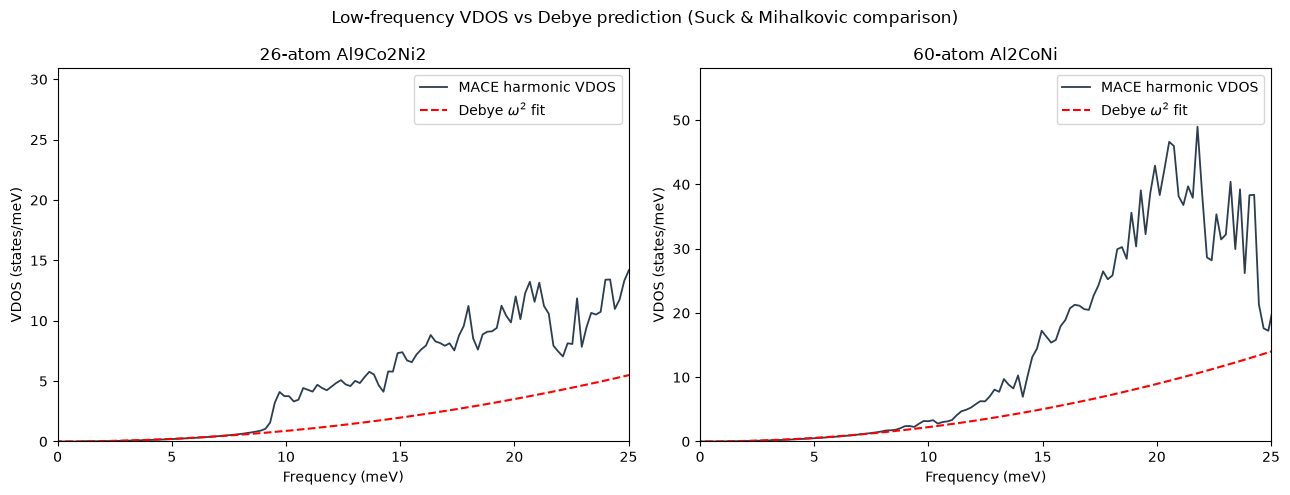

In [2]:
import phonopy, numpy as np, matplotlib.pyplot as plt

THz_to_meV = 4.13567

def get_vdos(yaml_path):
    ph = phonopy.load(yaml_path)
    ph.run_mesh([20, 20, 20])
    ph.run_total_dos(freq_pitch=0.05)
    d = ph.get_total_dos_dict()
    return d["frequency_points"] * THz_to_meV, d["total_dos"]

f26, dos26 = get_vdos("o2_phonon_26atom.yaml")
f60, dos60 = get_vdos("o2_phonon_60atom.yaml")

# --- fit a Debye omega^2 curve to the LOW-frequency region of each ---
# Debye: g(w) = a*w^2. Fit 'a' to the low-w rise (0-8 meV), then compare.
def debye_fit(f, dos, fit_max=8.0):
    mask = (f > 0.5) & (f < fit_max)          # low-frequency window, above zero
    a = np.sum(dos[mask] * f[mask]**2) / np.sum(f[mask]**4)   # least-squares for a*w^2
    return a

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (f, dos, label) in zip(axes, [(f26, dos26, "26-atom Al9Co2Ni2"),
                                       (f60, dos60, "60-atom Al2CoNi")]):
    a = debye_fit(f, dos)
    debye = a * f**2
    debye[f < 0] = 0
    ax.plot(f, dos, color="#2c3e50", lw=1.3, label="MACE harmonic VDOS")
    ax.plot(f, debye, color="red", lw=1.5, ls="--", label=r"Debye $\omega^2$ fit")
    ax.set_xlim(0, 25); ax.set_ylim(0, None)
    ax.set_xlabel("Frequency (meV)"); ax.set_ylabel("VDOS (states/meV)")
    ax.set_title(label); ax.legend()
    # quantify the low-w excess
    lowmask = (f > 0.5) & (f < 12)
    excess = np.trapezoid(np.maximum(dos[lowmask]-a*f[lowmask]**2, 0), f[lowmask])
    print(f"{label}: low-w excess above Debye (0-12 meV) = {excess:.2f} states")

plt.suptitle("Low-frequency VDOS vs Debye prediction (Suck & Mihalkovic comparison)")
plt.tight_layout()
plt.savefig("o2_debye_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

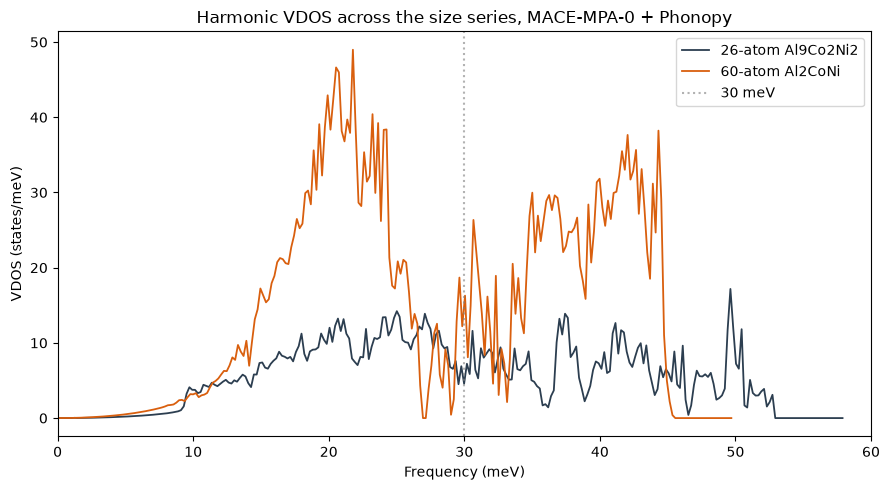

Saved size-series plot.


In [3]:
import matplotlib.pyplot as plt

# f26, dos26, f60, dos60 are already in memory from the Debye cell
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(f26, dos26, color="#2c3e50", lw=1.3, label="26-atom Al9Co2Ni2")
ax.plot(f60, dos60, color="#d95f0e", lw=1.3, label="60-atom Al2CoNi")
ax.axvline(30, color="gray", ls=":", alpha=0.6, label="30 meV")
ax.set_xlabel("Frequency (meV)")
ax.set_ylabel("VDOS (states/meV)")
ax.set_title("Harmonic VDOS across the size series, MACE-MPA-0 + Phonopy")
ax.set_xlim(0, 60)
ax.legend()
plt.tight_layout()
plt.savefig("o2_harmonic_vdos_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved size-series plot.")

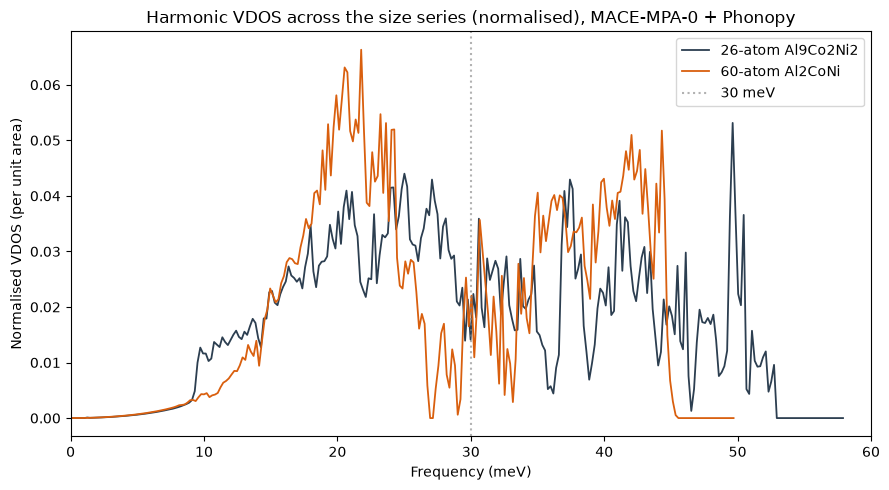

Saved normalised size-series plot.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# normalize each VDOS to unit area, so we compare SHAPE not atom count
def normalize(f, dos):
    area = np.trapezoid(dos, f)
    return dos / area

n26 = normalize(f26, dos26)
n60 = normalize(f60, dos60)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(f26, n26, color="#2c3e50", lw=1.3, label="26-atom Al9Co2Ni2")
ax.plot(f60, n60, color="#d95f0e", lw=1.3, label="60-atom Al2CoNi")
ax.axvline(30, color="gray", ls=":", alpha=0.6, label="30 meV")
ax.set_xlabel("Frequency (meV)")
ax.set_ylabel("Normalised VDOS (per unit area)")
ax.set_title("Harmonic VDOS across the size series (normalised), MACE-MPA-0 + Phonopy")
ax.set_xlim(0, 60)
ax.legend()
plt.tight_layout()
plt.savefig("o2_harmonic_vdos_series_normalised.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved normalised size-series plot.")